In [1]:
from tqdm.notebook import tqdm
import polars as pl
import matplotlib.pyplot as plt
import os
import re

In [2]:
DATASET_PATH = "BERTroid-published-datasets"
SELECTED_DATASET = "Data_RQ2_threashold_0B_8+M"

## The number of permissions per application manifest in Data_RQ2_threashold_0B__8+M

In [3]:
# Function to count the number of permissions
def count_permissions(permission: str):
    return len(permission.split())

# Function to plot the distribution of permissions in malware and benign applications
def permission_plot(filepath: str):
    data = pl.read_csv(filepath)
    data = data.with_columns(pl.col("permissions").map_elements(count_permissions, return_dtype=pl.Int64).alias("permissions_count"))
    data = data.group_by(["permissions_count", "Label"]).len()
    data = data.sort('permissions_count')
 
    malwares = data.filter(pl.col('Label') == 'M')
    benigns = data.filter(pl.col('Label') == 'B')
    
    plt.figure(figsize=(19.2, 10.8), dpi=100)
    plt.plot(malwares['permissions_count'], malwares['len'], marker="o", markersize=10, linewidth=3, color='blue', label='Malware')
    plt.plot(benigns['permissions_count'], benigns['len'], marker="o", markersize=10, linewidth=3, color='green', label='Benign')
    
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.xlabel("Number of permissions", fontsize=24)
    plt.ylabel("Number of Applications", fontsize=24)
    
    plt.xticks(
        ticks=range(0, 300, 50),
        fontsize=20
    )
    
    plt.ylim(0, 1300)
    plt.yticks(range(0, 1300, 100), fontsize=20)
    
    plt.legend(loc='upper right', fontsize=24)
    plt.show()

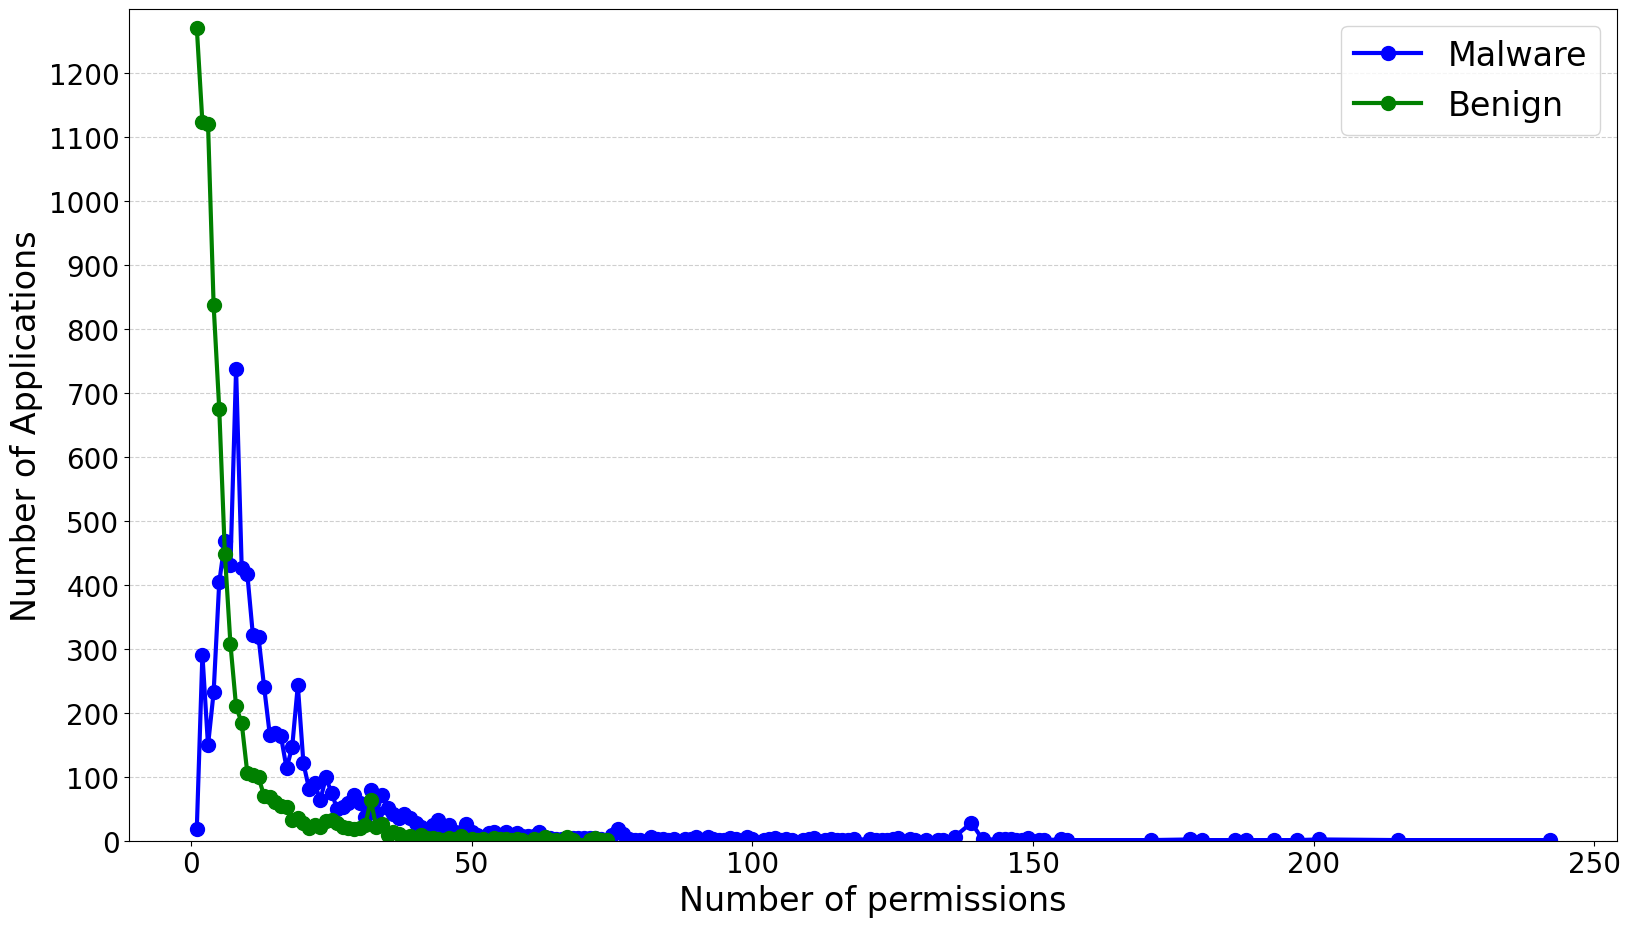

In [4]:
permission_plot(os.path.join(DATASET_PATH, SELECTED_DATASET + ".csv"))

## Selection of chosen overlapping parameters for dataset Data_RQ2_threashold_0B_8+M

In [5]:
# Function to sort permissions in alphabetical order
def sort_permissions(permission: str):
    return " ".join(sorted(permission.split(" ")))

#function to parse datasets provided by BERTroid's authors. We select only overlapping values. 
def parse_dataset(path):
    data = pl.read_csv(path)
    data_len = len(data)
    
    data = data.with_columns(pl.col("permissions").map_elements(sort_permissions, return_dtype=pl.Utf8))
    data = data.group_by(["permissions", "Label"]).len()
    data = data.pivot(values="len", index="permissions", on="Label", aggregate_function="sum")
    data = data.rename({"M": "Malware", "B": "Benign"})
    data = data.filter(pl.col("Malware").is_not_null() & pl.col("Benign").is_not_null())
    data = data.with_columns((pl.col("Malware") / data_len).alias("Malware_percentage") * 100,
                             (pl.col("Benign") / data_len).alias("Benign_percentage") * 100)
    return data

In [6]:
datasets = {}

# Process all datasets in the directory, should be 9
for file_name in tqdm(os.listdir(DATASET_PATH)):
    file_path = os.path.join(DATASET_PATH, file_name)
    if os.path.isfile(file_path):
        base_name, ext = os.path.splitext(file_name)   
        if ext == ".csv":
            datasets[base_name] = parse_dataset(file_path)

  0%|          | 0/9 [00:00<?, ?it/s]

In [7]:
#Selected permissions presented in the article
SELECTED_PERMISSIONS = [
"INTERNET",
"ACCESS_NETWORK_STATE INTERNET",
"INTERNET READ_PHONE_STATE",
"ACCESS_NETWORK_STATE ACCESS_WIFI_STATE INTERNET",
"INTERNET READ_PHONE_STATE WRITE_EXTERNAL_STORAGE",
"ACCESS_NETWORK_STATE INTERNET READ_PHONE_STATE WRITE_EXTERNAL_STORAGE",
"INTERNET READ_PHONE_STATE VIBRATE",
"ACCESS_COARSE_LOCATION INTERNET"
]

print(datasets[SELECTED_DATASET].filter(pl.col("permissions").is_in(SELECTED_PERMISSIONS)))

shape: (8, 5)
┌─────────────────────────────────┬────────┬─────────┬────────────────────┬───────────────────┐
│ permissions                     ┆ Benign ┆ Malware ┆ Malware_percentage ┆ Benign_percentage │
│ ---                             ┆ ---    ┆ ---     ┆ ---                ┆ ---               │
│ str                             ┆ u32    ┆ u32     ┆ f64                ┆ f64               │
╞═════════════════════════════════╪════════╪═════════╪════════════════════╪═══════════════════╡
│ INTERNET READ_PHONE_STATE WRIT… ┆ 35     ┆ 18      ┆ 0.122466           ┆ 0.238128          │
│ ACCESS_COARSE_LOCATION INTERNE… ┆ 204    ┆ 1       ┆ 0.006804           ┆ 1.387944          │
│ ACCESS_NETWORK_STATE INTERNET … ┆ 38     ┆ 126     ┆ 0.857259           ┆ 0.258539          │
│ ACCESS_NETWORK_STATE INTERNET   ┆ 213    ┆ 149     ┆ 1.013743           ┆ 1.449177          │
│ ACCESS_NETWORK_STATE ACCESS_WI… ┆ 31     ┆ 12      ┆ 0.081644           ┆ 0.210913          │
│ INTERNET READ_PHONE_STAT

In [8]:
sum_of_rows = datasets[SELECTED_DATASET].sum()
sum_of_occurence = (sum_of_rows["Malware"] + sum_of_rows["Benign"]).to_list()
sum_of_percentage = (sum_of_rows["Malware_percentage"] + sum_of_rows["Benign_percentage"]).to_list()
print(f"Sum of overllaping variables occurence in dataset: {sum_of_occurence[0]}\nSum of percentages:{sum_of_percentage[0]:.2f}%")

Sum of overllaping variables occurence in dataset: 3884
Sum of percentages:26.43%


## Different strategies for BERTroid model

In [9]:
max_estimated_accuracy = []
upper_bound = []

# Process all datasets in the directory, should be 9
for name, dataset in tqdm(datasets.items()):
    min_percentage = dataset.with_columns(
                             pl.min_horizontal(["Malware_percentage", "Benign_percentage"]).alias("min_percentage")
        )
    
    # Compute the max estimated accuracy as 100% minus the total sum of the smallest value from each row. 
    #Selected rows with overlapping values
    max_estimated_accuracy.append(100 - min_percentage["min_percentage"].sum())

    # Compute the upper bound as 100% minus the sum of Malware percentages
    upper_bound.append(100 - min_percentage["Malware_percentage"].sum())

different_strategies = pl.DataFrame({
    "Dataset": datasets.keys(),
    "Max estimated accuracy": max_estimated_accuracy,
    "Upper bound": upper_bound
})

  0%|          | 0/9 [00:00<?, ?it/s]

In [10]:
print(different_strategies)

shape: (9, 3)
┌─────────────────────────────┬────────────────────────┬─────────────┐
│ Dataset                     ┆ Max estimated accuracy ┆ Upper bound │
│ ---                         ┆ ---                    ┆ ---         │
│ str                         ┆ f64                    ┆ f64         │
╞═════════════════════════════╪════════════════════════╪═════════════╡
│ Data_RQ2_threashold_0B_8+M  ┆ 95.965437              ┆ 92.515989   │
│ Data_RQ2_threashold_12+M    ┆ 93.39153               ┆ 76.914683   │
│ Data_RQ2_threashold_0B_10+M ┆ 95.803529              ┆ 92.867362   │
│ Data_RQ2_Threashold_0B_6+M  ┆ 95.59663               ┆ 92.416418   │
│ Data_RQ2_threashold_10+M    ┆ 94.9874                ┆ 92.072465   │
│ Data_RQ2_threashold_3+M     ┆ 95.093981              ┆ 91.151523   │
│ Data_RQ2_threashold_8+M     ┆ 94.789825              ┆ 89.464019   │
│ Data_RQ2_threashold_1+M     ┆ 93.797031              ┆ 90.414209   │
│ Data_RQ2_threahsold_6+M     ┆ 94.99966               ┆ 91.419

## The probability that APK is malware given a specific permission using Bayes' Theorem

Here we use the MalBERT dataset, i.e., we extract application permissions from the applications provided by the authors. Bayesian analysis is better to calculate on a much larger data set.

The list of SHA-256 applications and their corresponding flags are located in the 'master_list' file. Flag 1 means malware, 0 benign.

In [11]:
MANIFESTS_PATH = "manifests"
FLAG_FILE = "master-list"

In [12]:
def extract_permissions(file_name):
    try:
        with open(os.path.join(MANIFESTS_PATH, file_name + ".xml"), 'r', encoding='utf-8', errors='ignore') as file:
            content = file.read()
            permissions = re.findall(r'android.permission\.([A-Z_]+)', content)
        return permissions
    except FileNotFoundError:
        return []

def is_file_available(file_name: str):
    file_path = os.path.join(MANIFESTS_PATH, file_name + ".xml")
    return os.path.exists(file_path)

In [13]:
available_files = pl.scan_csv(FLAG_FILE, has_header=False, new_columns=["SHA256", "Flag"])

available_files = available_files.with_columns(
    pl.col("SHA256").map_elements(is_file_available, return_dtype=pl.Int16).alias("file_exists")
).filter(pl.col("file_exists") == True).select(["SHA256", "Flag"])

available_files = available_files.group_by("Flag").agg(
    pl.count("SHA256").alias("Count")
).sort("Flag")

available_files = available_files.collect()

benign_count = available_files.row(0)[1]
malware_count = available_files.row(1)[1]
apk_count = malware_count + benign_count

malware_percent = malware_count / apk_count

In [14]:
permissions_list = pl.scan_csv(FLAG_FILE, has_header=False, new_columns=["SHA256", "Flag"])

permissions_list = permissions_list.with_columns(
    pl.col("SHA256").map_elements(extract_permissions, return_dtype=pl.List(pl.Utf8)).alias("Permissions")
)

permissions_list = permissions_list.filter(
    pl.col("Permissions").list.len() > 0
)

permissions_list = permissions_list.explode("Permissions")

permissions_list = permissions_list.group_by(["Flag", "Permissions"]).agg(
    pl.col("SHA256").n_unique().alias("Permissions_count")
)

permissions_list = permissions_list.collect()

permissions_list = permissions_list.pivot(
    on="Flag", 
    values="Permissions_count", 
    aggregate_function="sum"
).rename({"0": "Benign", "1": "Malware"}).fill_null(0)

permissions_list = permissions_list.with_columns(
    (pl.col("Malware") / malware_count).alias("Probability_in_malware"),
    (pl.col("Benign") / benign_count).alias("Probability_in_benig"),
    ((pl.col("Malware") + pl.col("Benign"))/apk_count).alias("Probability_in_apk"))

permissions_list = permissions_list.with_columns(
    ((pl.col("Probability_in_malware") * malware_percent) / pl.col("Probability_in_apk")).alias("Probability_APK_is_malware"))

permissions_list = permissions_list.select(["Permissions", "Probability_in_malware", "Probability_in_benig", "Probability_APK_is_malware"])

In [15]:
SELECTED_PERMISSIONS = [
"INTERNET",
"ACCESS_NETWORK_STATE",
"ACCESS_WIFI_STATE",
"READ_PHONE_STATE",
"MOUNT_UNMOUNT_FILESYSTEMS",
"WRITE_SETTINGS"
]

print(permissions_list.filter(pl.col("Permissions").is_in(SELECTED_PERMISSIONS)))

shape: (6, 4)
┌─────────────────────────┬────────────────────────┬──────────────────────┬────────────────────────┐
│ Permissions             ┆ Probability_in_malware ┆ Probability_in_benig ┆ Probability_APK_is_mal │
│ ---                     ┆ ---                    ┆ ---                  ┆ ware                   │
│ str                     ┆ f64                    ┆ f64                  ┆ ---                    │
│                         ┆                        ┆                      ┆ f64                    │
╞═════════════════════════╪════════════════════════╪══════════════════════╪════════════════════════╡
│ WRITE_SETTINGS          ┆ 0.632086               ┆ 0.07279              ┆ 0.783046               │
│ INTERNET                ┆ 0.998007               ┆ 0.97925              ┆ 0.297555               │
│ ACCESS_NETWORK_STATE    ┆ 0.994059               ┆ 0.930225             ┆ 0.307556               │
│ ACCESS_WIFI_STATE       ┆ 0.93858                ┆ 0.521332             ┆ 0